In [ ]:
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
import scanpy as sc

In [ ]:
adata = sc.read_h5ad('/nfs/team361/sb75/mintflow-reproducibility/datasets/benchmarking/sensitivity_analyses/eczema/segmentation_errors/segmentation_leakage_10pct/BK23_Lesional_Baseline.h5ad')

In [ ]:
adata2 = sc.read_h5ad('/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/15_10Samples_BEACON/0_PreProcessing/Outputs_Preprocessing/nb1_preprocessing_V1/PreProcessingDatedAt-13-01-2025-15-02-45/BK23_Lesional_Baseline.h5ad')

In [ ]:
adata.X.sum(0)[:, :10]

In [ ]:
adata2.X.sum(0)[:, :10]

In [ ]:
adata.X.sum(1)[:10]

In [ ]:
adata2.X.sum(1)[:10]

In [ ]:
# Set seed for reproducibility (optional)
np.random.seed(42)

# Add Label Noise

In [ ]:
file_names = [
    'BK23_Lesional_Baseline.h5ad',
    'BK30_Day_14.h5ad',
    'BK39_Non_lesional_Baseline.h5ad',
    'BK27_Non_lesional_Baseline.h5ad',
    'BK23_Non_lesional_Baseline.h5ad',
    'BK39_Lesional_Baseline.h5ad',
    'BK30_Lesional_Baseline.h5ad',
    'BK22_Lesional_Baseline.h5ad',
    'BK21_Lesional_Baseline.h5ad',
    'BK18_Lesional_Baseline.h5ad',    
]

copy_folder_path = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/15_10Samples_BEACON/0_PreProcessing/Outputs_Preprocessing/nb1_preprocessing_V1/PreProcessingDatedAt-13-01-2025-15-02-45'
paste_folder_path = '/nfs/team361/sb75/mintflow-reproducibility/datasets/benchmarking/sensitivity_analyses/eczema/label_noise'

In [ ]:
# Add label noise
# Percentages to shuffle
fractions = [0.1, 0.2, 0.3]

for file_name in file_names:
    adata = sc.read_h5ad(f"{copy_folder_path}/{file_name}")

    for frac in fractions:
        col_name = f"broad_celltypes_{int(frac*100)}pct_shuffle"
        
        # Start with a copy
        adata.obs[col_name] = adata.obs['broad_celltypes'].copy()
        
        # Number of rows to shuffle
        n = int(frac * len(adata.obs))
        
        # Random indices
        idx = np.random.choice(adata.obs.index, size=n, replace=False)
        
        # Shuffle values within those indices
        shuffled_values = (
            adata.obs.loc[idx, 'broad_celltypes']
            .sample(frac=1)
            .values
        )
        
        # Assign back
        adata.obs.loc[idx, col_name] = shuffled_values

    adata.write(f"{paste_folder_path}/{file_name}")

# Simulate Segmentation Errors by Neighborhood Count Leakage

In [ ]:
def build_neighbor_list_from_spatial(adata, spatial_key="spatial", k=6):
    coords = adata.obsm[spatial_key]
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nbrs.kneighbors(coords)
    return [row[1:] for row in indices]


def simulate_leakage_multiple_levels(
    adata,
    x_key="X",
    spatial_key="spatial",
    k=5,
    frac_cells=0.2,
    leakage_levels=(0.1, 0.2, 0.3),
    max_receiving_neighbors=2,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    X = adata.X if x_key == "X" else adata.layers[x_key]
    is_sparse = sp.issparse(X)

    if is_sparse:
        X_base = X.toarray().astype(np.int64)
    else:
        X_base = np.rint(np.asarray(X)).astype(np.int64)

    n_cells, n_genes = X_base.shape
    neighbors = build_neighbor_list_from_spatial(adata, spatial_key, k)

    selected = rng.choice(n_cells, size=int(frac_cells * n_cells), replace=False)

    for leak_frac in leakage_levels:
        X_sim = X_base.copy()

        for i in selected:
            cell_counts = X_sim[i].copy()
            total_counts = cell_counts.sum()
            if total_counts == 0:
                continue

            n_move = int(round(total_counts * leak_frac))
            if n_move == 0:
                continue

            n_move = min(n_move, total_counts)

            nbrs = neighbors[i]
            if len(nbrs) == 0:
                continue

            n_receivers = rng.integers(1, min(max_receiving_neighbors, len(nbrs)) + 1)
            receivers = rng.choice(nbrs, size=n_receivers, replace=False)

            # Sample existing transcripts without replacement
            gene_pool = np.repeat(np.arange(n_genes), cell_counts)
            moved_genes = rng.choice(gene_pool, size=n_move, replace=False)
            moved_gene_counts = np.bincount(moved_genes, minlength=n_genes)

            # Safe subtraction: cannot go negative now
            X_sim[i] -= moved_gene_counts

            # Distribute leaked transcripts to neighbors
            if n_receivers == 1:
                X_sim[receivers[0]] += moved_gene_counts
            else:
                receiver_split = rng.multinomial(n_move, np.ones(n_receivers) / n_receivers)

                rng.shuffle(moved_genes)
                start = 0
                for r, n_r in zip(receivers, receiver_split):
                    if n_r == 0:
                        continue
                    genes_r = moved_genes[start:start + n_r]
                    start += n_r
                    add = np.bincount(genes_r, minlength=n_genes)
                    X_sim[r] += add

        layer_name = f"segmentation_leakage_{int(leak_frac * 100)}pct"
        adata.layers[layer_name] = sp.csr_matrix(X_sim) if is_sparse else X_sim

        adata.obs[f"{layer_name}_is_corrupted"] = False
        adata.obs.loc[adata.obs.index[selected], f"{layer_name}_is_corrupted"] = True

        # Optional sanity check
        assert np.all(X_sim >= 0), f"Negative values found in {layer_name}"

    return adata

In [ ]:
file_names = [
    'BK23_Lesional_Baseline.h5ad',
    'BK30_Day_14.h5ad',
    'BK39_Non_lesional_Baseline.h5ad',
    'BK27_Non_lesional_Baseline.h5ad',
    'BK23_Non_lesional_Baseline.h5ad',
    'BK39_Lesional_Baseline.h5ad',
    'BK30_Lesional_Baseline.h5ad',
    'BK22_Lesional_Baseline.h5ad',
    'BK21_Lesional_Baseline.h5ad',
    'BK18_Lesional_Baseline.h5ad',    
]

copy_folder_path = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/15_10Samples_BEACON/0_PreProcessing/Outputs_Preprocessing/nb1_preprocessing_V1/PreProcessingDatedAt-13-01-2025-15-02-45'
paste_folder_path = '/nfs/team361/sb75/mintflow-reproducibility/datasets/benchmarking/sensitivity_analyses/eczema/segmentation_errors'

In [ ]:
np.set_printoptions(threshold=np.inf)

In [ ]:
# Perform neighbor leakage
for file_name in file_names:
    adata = sc.read_h5ad(f"{copy_folder_path}/{file_name}")

    adata = simulate_leakage_multiple_levels(
        adata,
        x_key="X",
        spatial_key="spatial",
        k=6,
        frac_cells=0.2,
        leakage_levels=(0.1, 0.2, 0.3),
        max_receiving_neighbors=2,
        random_state=42,
    )

    for leakage in ['segmentation_leakage_10pct', 'segmentation_leakage_20pct', 'segmentation_leakage_30pct']:
        adata.X = adata.layers[leakage].astype(np.float32).copy()
        adata.write(f"{paste_folder_path}/{leakage}/{file_name}")

# Analysis

In [1]:
import spatialdata as sd
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA

import rapids_singlecell as rsc

import os, sys
import pickle
import torch
import yaml
from scipy.sparse import issparse
import gc
from pprint import pprint
from tqdm.autonotebook import tqdm

from tqdm.autonotebook import tqdm
import anndata
import torch

import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata

/nfs/team361/aa36/PythonEnvs_2/env_Dec27th_mintflow/lib/python3.11/importlib/__init__.py:126: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/nfs/team361/aa36/PythonEnvs_2/env_Dec27th_mintflow/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


cuda:0
Loaded the checkpoint.


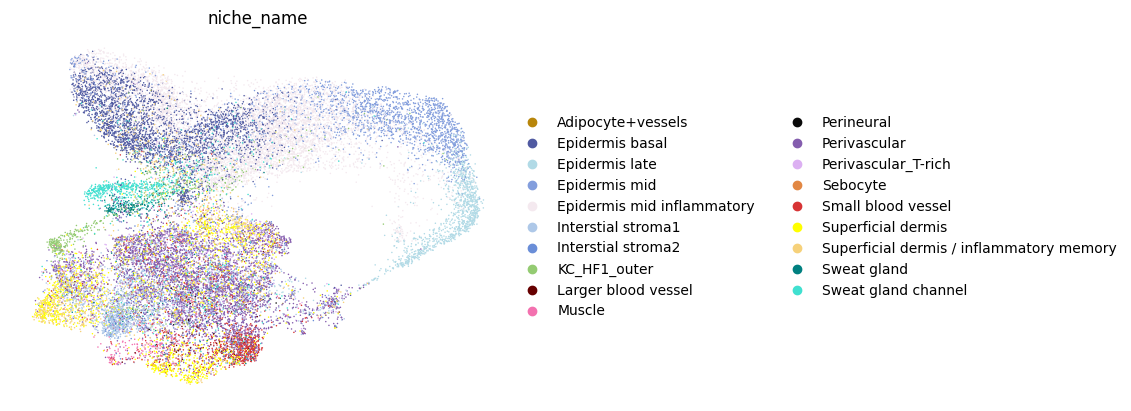

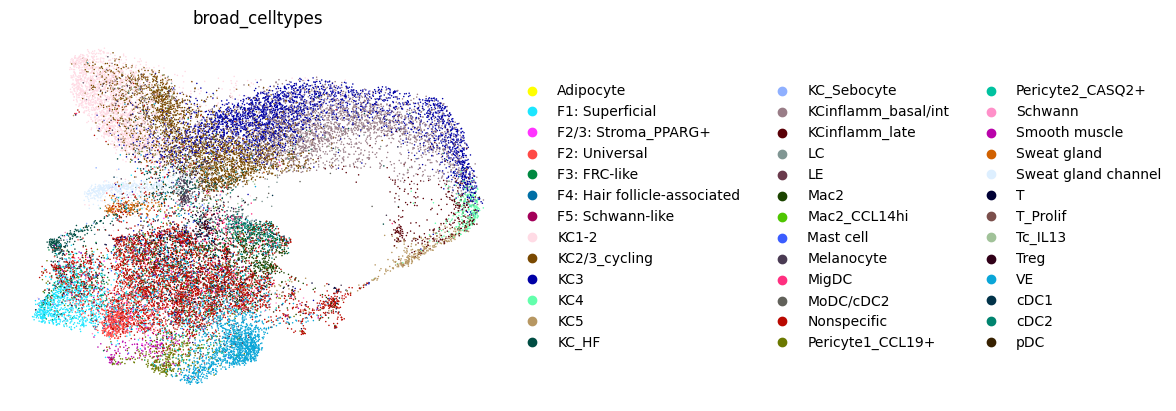

cuda:0
Loaded the checkpoint.


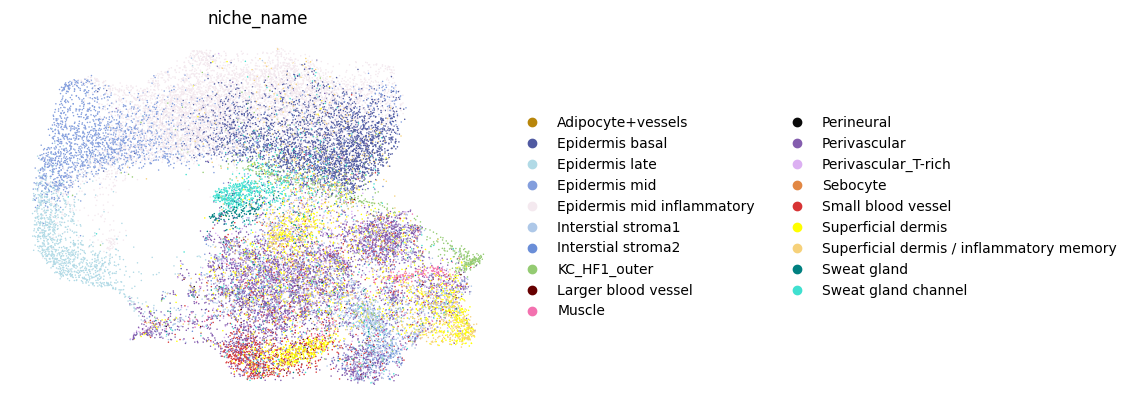

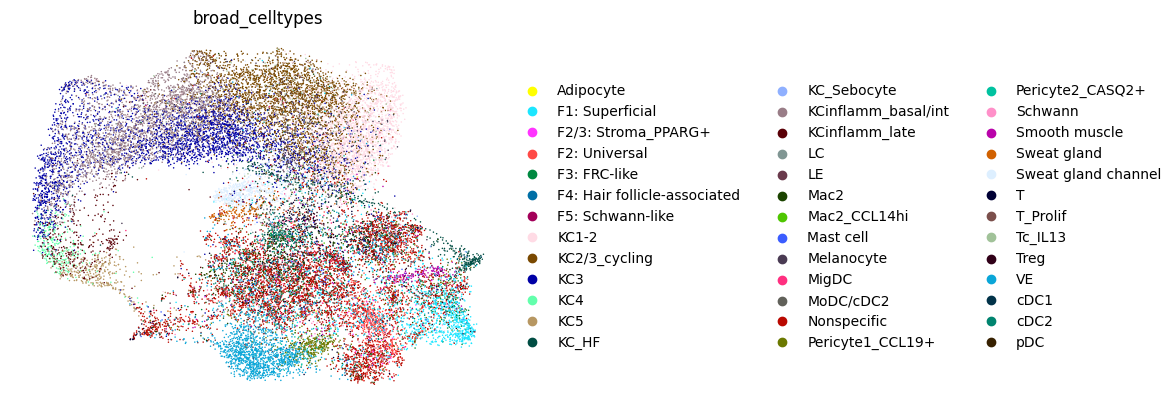

cuda:0
Loaded the checkpoint.


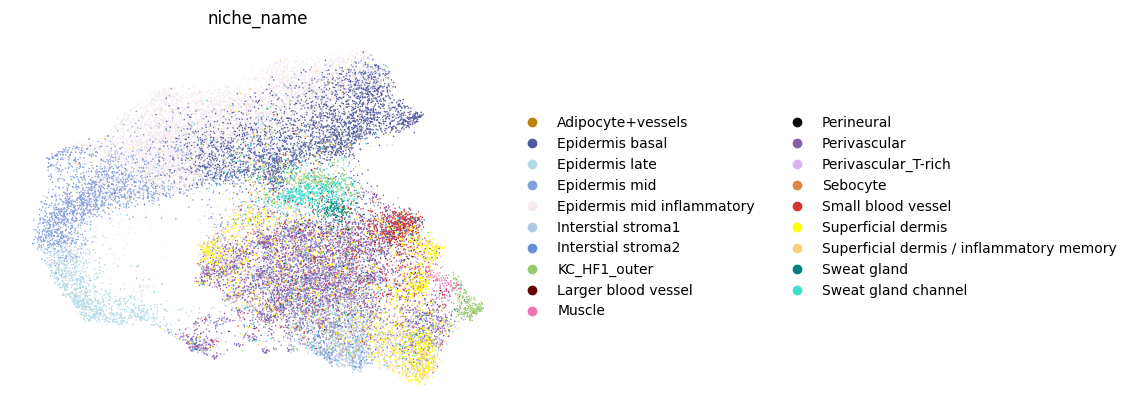

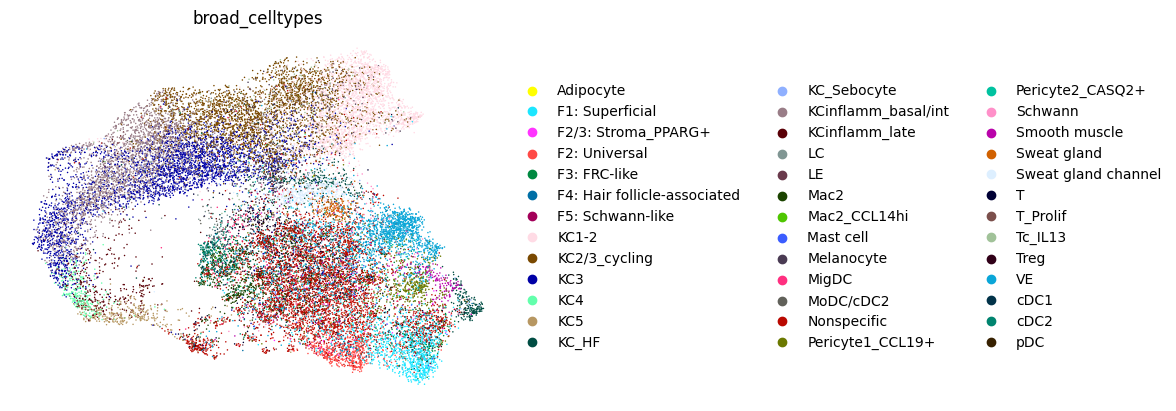

cuda:0
Loaded the checkpoint.


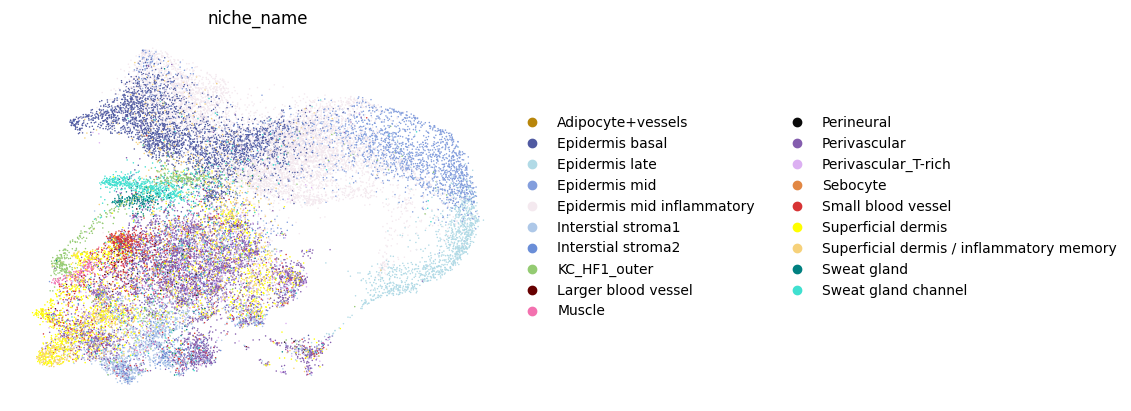

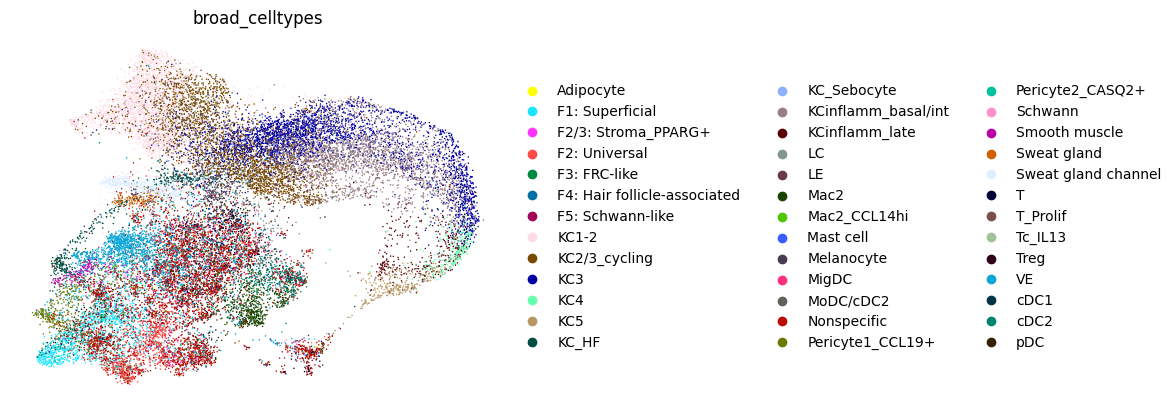

cuda:0
Loaded the checkpoint.


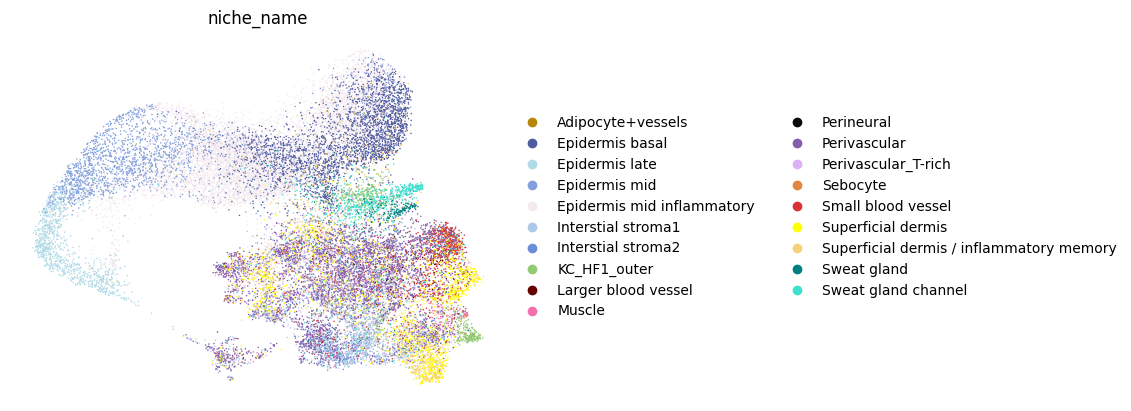

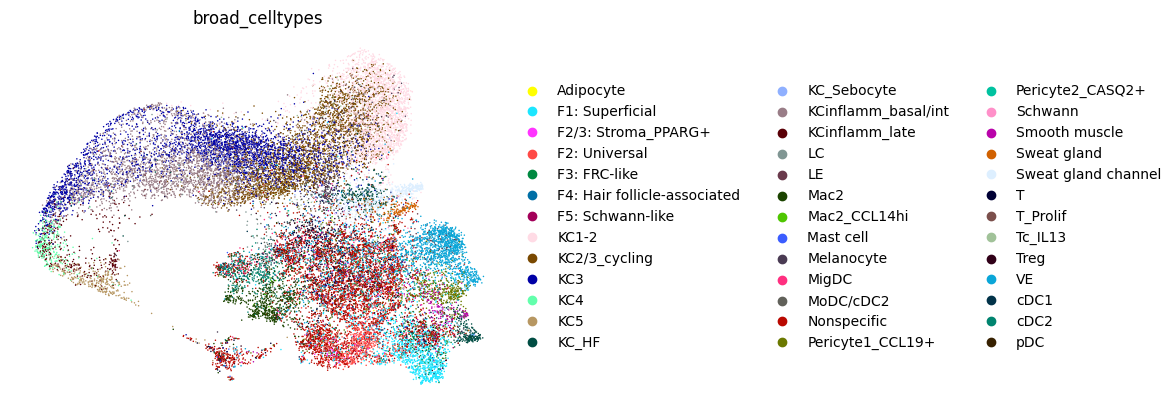

In [35]:
for experiment in ['15knn', '20knn', '10pctlabelnoise', '20pctlabelnoise', '30pctlabelnoise']: # '10knn', '10pctsegleakage', '20pctsegleakage', '30pctsegleakage'
    # Load checkpoint to retrieve AnnData
    path_checkpoint = f'/nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/sensitivity_analysis/eczema/{experiment}/checkpoint_epoch_19.pt'
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(device)

    checkpoint_mintflow = torch.load(
        path_checkpoint,
        map_location='cpu',
        weights_only=False
    )
    checkpoint_mintflow['model'].to(device)
    print("Loaded the checkpoint.")

    adata = checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].list_slice[0].adata.copy()

    # Load MintFlow predictions and add to AnnData
    with open(f'/nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/sensitivity_analysis/eczema/{experiment}/predictions_epoch_19.pkl', 'rb') as f:
       dict_predictions = pickle.load(f)
    
    for k in dict_predictions['TissueSection 0 (zero-based)'].keys():
        adata.obsm[k] = dict_predictions['TissueSection 0 (zero-based)'][k]

    pca = PCA(n_components=50, svd_solver="arpack")
    X_pca_barint = pca.fit_transform(adata.obsm["MintFlow_Xmic"])
    
    adata.obsm["X_PCA_mic"] = X_pca_barint
    adata.uns["X_PCA_mic"] = {
        'variance': pca.explained_variance_,
        'variance_ratio': pca.explained_variance_ratio_
    }
    
    rsc.pp.neighbors(adata, use_rep="X_PCA_mic", key_added="neighbors_mic")
    rsc.tl.umap(adata, neighbors_key="neighbors_mic", key_added="X_UMAP_mic")

    sc.pl.embedding(
        adata,
        color='niche_name',
        basis="X_UMAP_mic",
        frameon=False
    )

    sc.pl.embedding(
        adata,
        color='broad_celltypes',
        basis="X_UMAP_mic",
        frameon=False
    )

    os.makedirs(f'/nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/sensitivity_analysis/eczema/{experiment}/adata_output', exist_ok=True)
    os.makedirs(f'/nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/sensitivity_analysis/eczema/{experiment}/analysis', exist_ok=True)

    adata.write(f'/nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/sensitivity_analysis/eczema/{experiment}/adata_output/adata_mintflow_checkpoint_19.h5ad')